# Notebook for finding the parameters where recall is 1 and runtime is good

In [1]:
import os
import sys
import itertools


def find_project_root(target_folder="masteroppgave"):
    """Find the absolute path of a folder by searching upward."""
    currentdir = os.path.abspath("__file__")  # Get absolute script path
    while True:
        if os.path.basename(currentdir) == target_folder:
            return currentdir  # Found the target folder
        parentdir = os.path.dirname(currentdir)
        if parentdir == currentdir:  # Stop at filesystem root
            return None
        currentdir = parentdir  # Move one level up

# Example usage
project_root = find_project_root("masteroppgave")

if project_root:
    sys.path.append(project_root)
    print(f"Project root found: {project_root}")
else:
    raise RuntimeError("Could not find 'masteroppgave' directory")

from utils.helpers.measure_similarities import *

Project root found: /cluster/home/eivindoy/masteroppgave


In [52]:
CITY = "rome"
MEASURE = "dtw"
DATA_SIZE = [500]
SCHEME = "grid"
BUCKETING_METHOD = "loose"

## Read Bucketing Runtime CSV

In [53]:

folder_path = f"../../results_hashed/runtimes/bucketing/{CITY}/true_trajectories/{BUCKETING_METHOD}/{MEASURE}/"
file_name = f"runtimes_bucketing({BUCKETING_METHOD})_(true_trajectories)_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}.csv"
file_path = folder_path + file_name

runtime_bucketing = pd.read_csv(file_path, index_col=0)
runtime_bucketing.head()



runtime_bucketing.head(5)

,Measure,Resolution,Layers,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
City,,,,,,,,
rome,grid_dtw_cy,0.02,3,500,32.227,7.402,0.213,39.842
rome,grid_dtw_cy,0.02,4,500,34.491,9.991,0.189,44.671
rome,grid_dtw_cy,0.03,1,500,31.211,1.680,0.043,32.934
rome,grid_dtw_cy,0.03,2,500,34.994,3.442,0.088,38.524
rome,grid_dtw_cy,0.03,3,500,37.207,5.013,0.134,42.354


## Read No Bucketing Runtime CSV

In [54]:

folder_path = f"../../results_hashed/runtimes/no_bucketing/{CITY}/{MEASURE}/"
file_name = f"runtimes_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}_no_bucketing.csv"
file_path = folder_path + file_name

runtime_no_bucketing = pd.read_csv(file_path)
runtime_no_bucketing.head(5)


,City,Measure,Resolution,Layers,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Total time (Seconds)
0,rome,dtw,0.1,3,500,42.201,1.585,43.786
1,rome,dtw,0.2,3,500,20.396,0.906,21.302
2,rome,dtw,0.3,3,500,11.823,0.662,12.485
3,rome,dtw,0.4,3,500,8.325,0.654,8.979
4,rome,dtw,0.5,3,500,6.316,0.580,6.896


## Read No Bucketing Correlation

In [55]:
DATA_SIZE_WITHOUT_BRACKETS = DATA_SIZE[0]
folder_path = f"../correlation/no_bucketing_correlation_values/"
file_name = f"correlation_results_{CITY}_grid_no_bucketing_{DATA_SIZE_WITHOUT_BRACKETS}.csv"
file_path = folder_path + file_name

correlation_no_bucketing = pd.read_csv(file_path, index_col=0)
correlation_no_bucketing.head(5)

#Merge runtime_no_bucketing and correlation_no_bucketing on columns "Resolution" and "Layers"
runtime_no_bucketing = pd.merge(runtime_no_bucketing, correlation_no_bucketing, on=["Resolution", "Layers"])
runtime_no_bucketing.head(5)


,City,Measure,Resolution,Layers,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Total time (Seconds),Correlation
0,rome,dtw,0.1,3,500,42.201,1.585,43.786,0.662
1,rome,dtw,0.2,3,500,20.396,0.906,21.302,0.617
2,rome,dtw,0.3,3,500,11.823,0.662,12.485,0.597
3,rome,dtw,0.4,3,500,8.325,0.654,8.979,0.588
4,rome,dtw,0.5,3,500,6.316,0.580,6.896,0.593


## Read Bucket Evaluation CSV

In [56]:
folder_path = f"../../results_hashed/bucket_evaluation/{BUCKETING_METHOD}/"
file_name = f"{CITY}_{MEASURE}_{SCHEME}_{DATA_SIZE_WITHOUT_BRACKETS}_{BUCKETING_METHOD}.csv"
file_path = folder_path + file_name

bucket_evaluation = pd.read_csv(file_path, index_col=0)

bucket_evaluation.head(5)

,Measure,Resolution,Layers,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Number of buckets,Avg Bucket size,Avg Buckets with >1 Trajectory,Avg Largest Bucket Size,Avg Correlation Coefficient
City,,,,,,,,,,,,,
rome,dtw,0.02,1,500,0.1,0.002,0.990,0.004,10189.292,2.339,4552.417,30.792,1.0
rome,dtw,0.02,1,500,0.2,0.013,0.959,0.026,10189.292,2.339,4552.417,30.792,1.0
rome,dtw,0.02,1,500,0.3,0.038,0.916,0.072,10189.292,2.339,4552.417,30.792,1.0
rome,dtw,0.02,1,500,0.4,0.071,0.860,0.132,10189.292,2.339,4552.417,30.792,1.0
rome,dtw,0.02,1,500,0.5,0.112,0.795,0.197,10189.292,2.339,4552.417,30.792,1.0


In [57]:
# First, filter the bucket_evaluation dataframe
filtered_eval = bucket_evaluation[
    (bucket_evaluation["Avg Recall"] == 1) &
    (bucket_evaluation["Threshold"] == 0.1)
]

# Select only the necessary columns from runtime_bucketing
runtime_selected = runtime_bucketing[[
    "Resolution", "Layers",
    "Average Similarity Computation Time (Seconds)",
    "Average Hash Generation Time (Seconds)",
    "Average Bucket Distribution Time (Seconds)",
    "Total time (Seconds)"
]]

# Merge using only Diameter, Layers, and Disks as keys
runtime_bucketing_and_bucket_evaluation = filtered_eval.merge(
    runtime_selected,
    on=["Resolution", "Layers"],
    how="left"
)

columns_to_show = [
    "Resolution", "Layers",
    "Avg Correlation Coefficient",
    "Avg Recall", "Threshold",
    "Average Similarity Computation Time (Seconds)",
    "Average Hash Generation Time (Seconds)",
    "Average Bucket Distribution Time (Seconds)",
    "Total time (Seconds)"
]

runtime_bucketing_and_bucket_evaluation.head(5)



,Measure,Resolution,Layers,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Number of buckets,Avg Bucket size,Avg Buckets with >1 Trajectory,Avg Largest Bucket Size,Avg Correlation Coefficient,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
0,dtw,0.02,3,500,0.1,0.002,1.0,0.003,30558.250,2.339,13685.792,33.083,1.0,32.227,7.402,0.213,39.842
1,dtw,0.02,4,500,0.1,0.002,1.0,0.003,40756.417,2.339,18223.000,33.542,1.0,34.491,9.991,0.189,44.671
2,dtw,0.03,1,500,0.1,0.002,1.0,0.003,7411.333,3.040,3916.250,48.250,1.0,31.211,1.680,0.043,32.934
3,dtw,0.03,2,500,0.1,0.001,1.0,0.003,14830.083,3.039,7840.542,49.500,1.0,34.994,3.442,0.088,38.524
4,dtw,0.03,3,500,0.1,0.001,1.0,0.003,22215.042,3.040,11771.583,50.083,1.0,37.207,5.013,0.134,42.354


In [58]:
# Sort the merged dataframe by Avg Correlation Coefficient in descending order
runtime_bucketing_and_bucket_evaluation_sorted = runtime_bucketing_and_bucket_evaluation.sort_values(
    by="Total time (Seconds)",
    ascending=True
)
runtime_bucketing_and_bucket_evaluation_sorted.head(10)

#show only these columns
columns_to_show = [
    "Resolution", "Layers",
    "Avg Correlation Coefficient",
    "Avg Recall", "Threshold",
    "Average Similarity Computation Time (Seconds)",
    "Average Hash Generation Time (Seconds)",
    "Average Bucket Distribution Time (Seconds)",
    "Total time (Seconds)"
]
runtime_bucketing_and_bucket_evaluation_sorted = runtime_bucketing_and_bucket_evaluation_sorted[columns_to_show]

#extract lowest runtime Total time (Seconds) in the runtime_bucketing_and_bucket_evaluation_sorted dataframe
lowest_runtime = runtime_bucketing_and_bucket_evaluation_sorted.iloc[0]

lowest_runtime = runtime_bucketing_and_bucket_evaluation_sorted["Total time (Seconds)"].min()


print(lowest_runtime)


runtime_bucketing_and_bucket_evaluation_sorted.head(5)



32.934


,Resolution,Layers,Avg Correlation Coefficient,Avg Recall,Threshold,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
2,0.03,1,1.0,1.0,0.1,31.211,1.680,0.043,32.934
6,0.04,1,1.0,1.0,0.1,34.712,1.292,0.037,36.041
10,0.05,1,1.0,1.0,0.1,37.291,1.178,0.036,38.505
3,0.03,2,1.0,1.0,0.1,34.994,3.442,0.088,38.524
0,0.02,3,1.0,1.0,0.1,32.227,7.402,0.213,39.842


In [59]:
print(runtime_no_bucketing.head(5))


# Merge runtime_no_bucketing with merged_df_sorted top 5 rows
runtime_no_bucketing_vs_runtime_bucketing = runtime_bucketing_and_bucket_evaluation_sorted.head(5)
runtime_no_bucketing_vs_runtime_bucketing = runtime_no_bucketing_vs_runtime_bucketing.merge(
    runtime_no_bucketing,
    on=["Resolution", "Layers"],
    how="left",
    suffixes=("", "_no_bucketing")
)
# Rename the columns to avoid confusion
runtime_no_bucketing_vs_runtime_bucketing.rename(
    columns={
        "Average Similarity Computation Time (Seconds)": "Average Similarity Computation Time (Seconds)_bucketing",
        "Average Hash Generation Time (Seconds)": "Average Hash Generation Time (Seconds)_bucketing",
        "Average Bucket Distribution Time (Seconds)": "Average Bucket Distribution Time (Seconds)_bucketing",
        "Total time (Seconds)": "Total time (Seconds)_bucketing"
    },
    inplace=True
)




runtime_no_bucketing_vs_runtime_bucketing.head()


   City Measure  Resolution  Layers  Size  \
0  rome     dtw         0.1       3   500   
1  rome     dtw         0.2       3   500   
2  rome     dtw         0.3       3   500   
3  rome     dtw         0.4       3   500   
4  rome     dtw         0.5       3   500   

   Average Similarity Computation Time (Seconds)  \
0                                         42.201   
1                                         20.396   
2                                         11.823   
3                                          8.325   
4                                          6.316   

   Average Hash Generation Time (Seconds)  Total time (Seconds)  Correlation  
0                                   1.585                43.786        0.662  
1                                   0.906                21.302        0.617  
2                                   0.662                12.485        0.597  
3                                   0.654                 8.979        0.588  
4                    

,Resolution,Layers,Avg Correlation Coefficient,Avg Recall,Threshold,Average Similarity Computation Time (Seconds)_bucketing,Average Hash Generation Time (Seconds)_bucketing,Average Bucket Distribution Time (Seconds)_bucketing,Total time (Seconds)_bucketing,City,Measure,Size,Average Similarity Computation Time (Seconds)_no_bucketing,Average Hash Generation Time (Seconds)_no_bucketing,Total time (Seconds)_no_bucketing,Correlation
0,0.03,1,1.0,1.0,0.1,31.211,1.680,0.043,32.934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.04,1,1.0,1.0,0.1,34.712,1.292,0.037,36.041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.05,1,1.0,1.0,0.1,37.291,1.178,0.036,38.505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.03,2,1.0,1.0,0.1,34.994,3.442,0.088,38.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02,3,1.0,1.0,0.1,32.227,7.402,0.213,39.842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


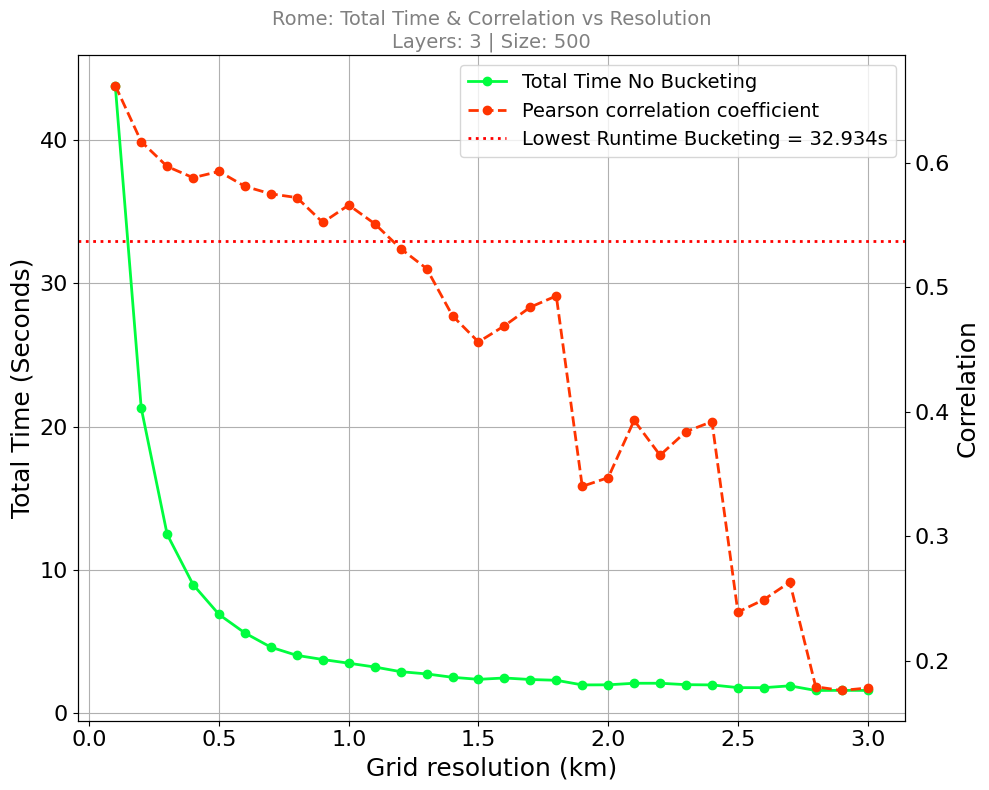

In [60]:
# Filter the runtime_no_bucketing dataframe to only include the rows where Layers = 3
filtered_runtime_no_bucketing = runtime_no_bucketing[runtime_no_bucketing["Layers"] == 3]

# print(filtered_runtime_no_bucketing[["Resolution", "Correlation"]])


import matplotlib.pyplot as plt
import numpy as np

def plot_total_time_vs_resolution(
    df,
    city: str,
    measure: str = "dtw",
    layers: int = 3,
    size: int = 500,
    lowest_runtime: float = None,  # Add this argument
):
    """
    Plots the relationship between grid resolution and total time (in seconds),
    and overlays correlation on a secondary y-axis with clear labels.
    Adds a horizontal line for the externally provided lowest total runtime.
    """

    # Filter the DataFrame
    filtered = df[
        (df['City'] == city) &
        (df['Measure'] == measure) &
        (df['Layers'] == layers) &
        (df['Size'] == size)
    ].sort_values(by='Resolution')

    # Extract values
    res = filtered['Resolution'].values
    total_time = filtered['Total time (Seconds)'].values
    corr = filtered['Correlation'].astype(float).values

    # Plot
    fig, ax1 = plt.subplots(figsize=(10, 8), dpi=100)
    ax2 = ax1.twinx()
    cmap = plt.get_cmap("gist_ncar")

    line1 = ax1.plot(res, total_time, color=cmap(0.3), marker='o', lw=2, label='Total Time No Bucketing')[0]
    line2 = ax2.plot(res, corr, color=cmap(0.7), marker='o', lw=2, linestyle='--', label='Pearson correlation coefficient')[0]

    # Use provided lowest_runtime if available
    if lowest_runtime is not None:
        line3 = ax1.axhline(
            y=lowest_runtime,
            color='red',
            linestyle=':',
            linewidth=2,
            label=f'Lowest Runtime Bucketing = {lowest_runtime:.3f}s'
        )
        lines = [line1, line2, line3]
    else:
        lines = [line1, line2]

    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper right", fontsize=14)

    # Axis labels and styling
    ax1.set_xlabel("Grid resolution (km)", fontsize=18)
    ax1.set_ylabel("Total Time (Seconds)", fontsize=18)
    ax2.set_ylabel("Correlation", fontsize=18)
    

    ax1.tick_params(axis="both", which="major", labelsize=16)
    ax2.tick_params(axis="both", which="major", labelsize=16)

    ax1.set_title(
        f"{city.capitalize()}: Total Time & Correlation vs Resolution\nLayers: {layers} | Size: {size}",
        fontsize=14,
        color='grey'
    )

    ax1.grid(True)
    fig.tight_layout()
    plt.show()




plot_total_time_vs_resolution(
    filtered_runtime_no_bucketing,
    city=CITY,
    measure="dtw",
    layers=3,
    size=500,
    lowest_runtime=lowest_runtime  # Pass the value from your earlier cell
)


# filtered_runtime_no_bucketing.head(5)
